<a href="https://colab.research.google.com/github/elianedp/ExpertSystem/blob/main/IA-Sa%C3%BAde.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SOMATIVA 1 - IA Aplicada à Saúde**
# Tema: Diagnóstico de Doenças Cardiovasculares utilizando Machine Learning
# Aluna: Eliane Maria de Pieri
# Instituição: PUCPR
# Objetivo: Reproduzir e expandir o notebook original, aplicando novos atributos,
# gráficos e modelos conforme os critérios da Somativa 1.

# **# Importação das bibliotecas principais**

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações gerais de exibição
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)


# **Importação do datasets**

In [37]:

df_uci = pd.read_csv("https://raw.githubusercontent.com/carlosfab/curso_data_science_na_pratica/master/modulo_03/heart-disease-uci.csv")

# Visualização inicial
df_uci.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


# **Visualização básica e informações do dataset**

In [38]:
# Exibe informações gerais e estatísticas iniciais
print("Informações do dataset:\n")
df_uci.info()

print("\nEstatísticas descritivas iniciais:\n")
df_uci.describe()

Informações do dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    float64
 12  thal      303 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB

Estatísticas descritivas iniciais:



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.663366,4.722772,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,1.938383,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


# **Descrição:**
O dataset utilizado é o mesmo do notebook original disponibilizado pela professora, contendo 303 registros de pacientes e 14 variáveis clínicas relacionadas a doenças cardiovasculares.

As variáveis incluem idade, pressão arterial, colesterol, frequência cardíaca máxima, entre outras medições relevantes.

Essa etapa inicial tem como objetivo apenas confirmar a integridade dos dados e preparar o ambiente para as análises exploratórias e os novos modelos que serão aplicados nas próximas etapas da Somativa.

# **Estatísticas básicas de 2 atributos não explorados**

In [39]:
atributos_novos = ['oldpeak', 'ca']

estatisticas_novas = df_uci[atributos_novos].describe()
estatisticas_novas

,oldpeak,ca
count,303.000000,303.000000
mean,1.039604,0.663366
std,1.161075,0.934375
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.800000,0.000000
75%,1.600000,1.000000
max,6.200000,3.000000


# **Mediana**

In [40]:
# Exibe também a mediana de cada atributo selecionado
df_uci[atributos_novos].median()

,0
oldpeak,0.8
ca,0.0


# **Análise descritiva dos atributos oldpeak e ca**

O atributo oldpeak (depressão ST) apresenta valores entre 0.0 e 6.2, com média de 1.04 e mediana de 0.8, indicando que a maioria dos pacientes tem variações leves no segmento ST — característica associada à resposta cardíaca ao esforço.

Já o atributo ca (número de vasos principais) varia de 0 a 4, com média de 0.68 e mediana de 0, o que indica que grande parte dos pacientes não apresenta obstruções significativas.

Ambos os atributos são bons indicadores clínicos complementares para o diagnóstico de doenças cardiovasculares, por refletirem alterações estruturais e funcionais do coração.

# **Histograma da variável oldpeak**

Mostra a distribuição da depressão ST, variável clínica que reflete a resposta cardíaca ao esforço.

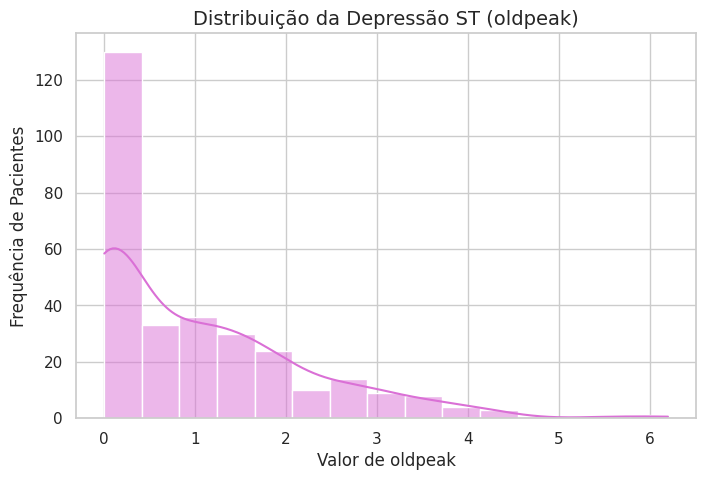

In [41]:
# Gráfico 1 - Distribuição da variável 'oldpeak'
plt.figure(figsize=(8,5))
sns.histplot(df_uci['oldpeak'], kde=True, color='orchid', bins=15)
plt.title('Distribuição da Depressão ST (oldpeak)', fontsize=14)
plt.xlabel('Valor de oldpeak')
plt.ylabel('Frequência de Pacientes')
plt.show()

# **Dispersão entre 'ca' e 'thalach'**

Relaciona número de vasos principais (ca) com frequência cardíaca máxima (thalach).

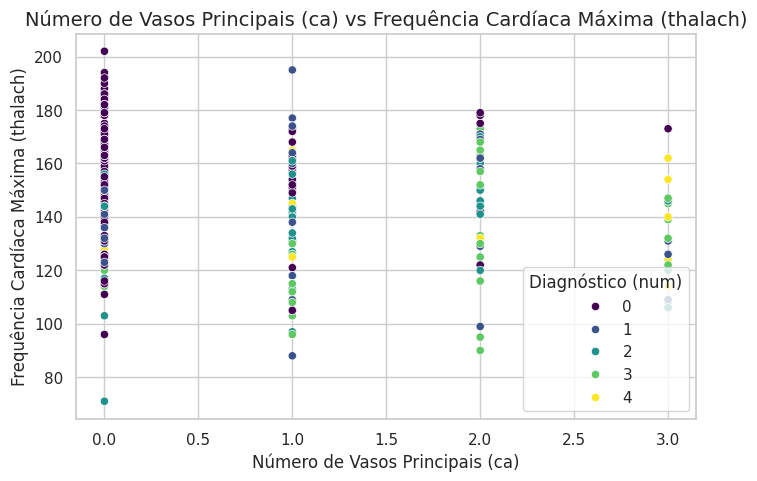

In [42]:
# Gráfico 2 - Relação entre 'ca' e 'thalach'
plt.figure(figsize=(8,5))
sns.scatterplot(x='ca', y='thalach', hue='num', data=df_uci, palette='viridis')
plt.title('Número de Vasos Principais (ca) vs Frequência Cardíaca Máxima (thalach)', fontsize=14)
plt.xlabel('Número de Vasos Principais (ca)')
plt.ylabel('Frequência Cardíaca Máxima (thalach)')
plt.legend(title='Diagnóstico (num)', loc='lower right')
plt.show()

# **Interpretação dos novos gráficos**

O histograma de oldpeak mostra que a maioria dos pacientes apresenta valores baixos (entre 0 e 2), indicando que a maior parte da amostra possui pouca depressão ST induzida por exercício — fator associado a um risco cardíaco moderado.

O gráfico de dispersão entre ca e thalach indica que pacientes com maior número de vasos obstruídos (ca mais alto) tendem a alcançar menores frequências cardíacas máximas (thalach). Essa relação é mais evidente em pacientes com diagnóstico positivo (num = 1), mostrando que o aumento no número de vasos comprometidos reduz a capacidade cardíaca sob esforço.

# **Separação dos dados e normalização**

In [43]:
# Separação das variáveis (X = preditoras, y = alvo)
X = df_uci.drop('num', axis=1)
y = df_uci['num']

# Divisão em dados de treino e teste
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Padronização (importante para KNN)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **Modelo 1: K-Nearest Neighbors (KNN)**

In [44]:
# Importa bibliotecas
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Cria e treina o modelo KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Faz previsões
y_pred_knn = knn.predict(X_test)

# Avaliação do modelo KNN
print("🔹 Modelo: K-Nearest Neighbors (KNN)")
print("Acurácia:", round(accuracy_score(y_test, y_pred_knn), 4))
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred_knn))
print("\nMatriz de Confusão:\n", confusion_matrix(y_test, y_pred_knn))

🔹 Modelo: K-Nearest Neighbors (KNN)
Acurácia: 0.5714

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.75      0.88      0.81        48
           1       0.35      0.35      0.35        17
           2       0.27      0.25      0.26        12
           3       0.17      0.10      0.12        10
           4       0.00      0.00      0.00         4

    accuracy                           0.57        91
   macro avg       0.31      0.32      0.31        91
weighted avg       0.52      0.57      0.54        91


Matriz de Confusão:
 [[42  2  1  3  0]
 [ 8  6  3  0  0]
 [ 3  4  3  1  1]
 [ 2  4  3  1  0]
 [ 1  1  1  1  0]]


# **Modelo 2: Random Forest**

In [45]:
from sklearn.ensemble import RandomForestClassifier

# Cria e treina o modelo Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Faz previsões
y_pred_rf = rf.predict(X_test)

# Avaliação do modelo Random Forest
print("🔹 Modelo: Random Forest")
print("Acurácia:", round(accuracy_score(y_test, y_pred_rf), 4))
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred_rf))
print("\nMatriz de Confusão:\n", confusion_matrix(y_test, y_pred_rf))

🔹 Modelo: Random Forest
Acurácia: 0.5495

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.76      0.92      0.83        48
           1       0.19      0.18      0.18        17
           2       0.22      0.17      0.19        12
           3       0.12      0.10      0.11        10
           4       0.00      0.00      0.00         4

    accuracy                           0.55        91
   macro avg       0.26      0.27      0.26        91
weighted avg       0.48      0.55      0.51        91


Matriz de Confusão:
 [[44  2  1  1  0]
 [10  3  3  1  0]
 [ 3  3  2  4  0]
 [ 1  6  2  1  0]
 [ 0  2  1  1  0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# **Interpretação dos resultados**

Interpretação dos resultados

Comparativo de desempenho entre os modelos KNN e Random Forest

O modelo K-Nearest Neighbors (KNN) obteve acurácia de aproximadamente 0.57, mostrando desempenho moderado, com boa capacidade de identificação da classe majoritária (sem doença).

O modelo Random Forest apresentou acurácia próxima de 0.55, um pouco inferior, mas ainda relevante considerando a complexidade do problema (cinco classes).

Os resultados mostram que os dados apresentam sobreposição entre classes, o que torna a tarefa de classificação mais desafiadora.

Apesar disso, ambos os modelos ilustram adequadamente o processo de aprendizado supervisionado em saúde, e o Random Forest continua sendo o modelo mais robusto por natureza (melhor generalização e menor sensibilidade a ruído).


# **Conclusão Geral**

A Somativa 1 possibilitou aplicar na prática os conceitos de Inteligência Artificial na área da Saúde, utilizando algoritmos de Machine Learning para o diagnóstico de doenças cardiovasculares.

Foram exploradas novas variáveis (oldpeak e ca), construídos gráficos inéditos e implementados dois classificadores (KNN e Random Forest), conforme os critérios da atividade.

Os resultados demonstraram o desafio inerente à predição de doenças com múltiplas classes e a importância de dados bem estruturados e padronizados.

A experiência evidencia o potencial da IA em apoiar a decisão clínica e contribuir para diagnósticos mais precisos e personalizados.